## References

1. Logan CHA, Fotopoulou S. Unsupervised star, galaxy, QSO classification. Astronomy & Astrophysics. 

https://www.aanda.org/articles/aa/full_html/2020/01/aa36648-19/aa36648-19.html#S14

# Density-Based Clustering Workflow for Astronomical Object Clustering

This notebook is a **density-based clustering workflow** for clustering astronomical objects using DBSCAN and HDBSCAN.

- it uses **same feature set** as other clustering methods 
- it keeps the **same evaluation family** used in the earlier notebook
- it uses the **scaled data already prepared beforehand**
- This notebook aims to explain:
  1. why density-based clustering is appropriate,
  2. how to choose hyperparameters for DBSCAN,
  3. how to choose hyperparameters for HDBSCAN,
  4. how to evaluate the fitted model(s).


Per project decision, the model is trained on:

- `u-g`
- `g-r`
- `r-i`
- `i-z`
- `redshift_log`

## 1. Pipeline overview

The end-to-end pipeline in this notebook is:

1. **Load the scaled dataset** from `../astral_data.csv`.
2. **Justify DBSCAN** as the baseline for density-based clustering on standardized features.
3. **Perform hyperparameter tuning** for DBSCAN using grid search over (eps, min_samples) to maximize silhouette score.
4. **Evaluate DBSCAN** with metrics including ARI, NMI, silhouette, Calinski-Harabasz, Davies-Bouldin, noise percentage, cluster composition, confusion matrix, and PCA visualization.
5. **Introduce HDBSCAN** for handling varying densities and cluster sizes.
6. **Tune HDBSCAN parameters** including min_cluster_size and min_samples via grid search.
7. **Evaluate HDBSCAN models** using the same metrics as DBSCAN.
8. **Interpret results** in terms of cluster separation, outliers, and performance on astronomical classes.

## 2. Why try DBSCAN and HDBSCAN?

Density-based clustering methods like DBSCAN and HDBSCAN are particularly suited for astronomical datasets where clusters may have arbitrary shapes and varying densities. Unlike centroid-based methods (e.g., K-Means), which assume spherical clusters, density-based approaches can identify clusters of any shape and handle noise effectively.

DBSCAN groups points that are closely packed together, marking points in low-density regions as outliers. This is advantageous for astronomical data where stars, galaxies, and quasars may not form compact, spherical groups in feature space.

HDBSCAN extends DBSCAN by incorporating hierarchical clustering, allowing it to adapt to varying densities and providing more stable cluster detection. It is robust in complex datasets where traditional methods struggle to separate overlapping or unevenly distributed regions.

In this notebook, we explore both DBSCAN and HDBSCAN to compare their performance on the scaled photometric features, aiming to better capture the underlying structure of astronomical objects without assuming predefined cluster shapes.

## 3. DBSCAN Baseline

We adopt DBSCAN as the baseline model for density-based clustering. A grid search is conducted over the hyperparameters *(eps, min_samples)* to identify the optimal configuration. Model selection is performed by maximising the silhouette score, which evaluates cluster cohesion and separation in a fully unsupervised manner.

To provide a comprehensive evaluation of clustering performance, the following metrics are reported:

- Adjusted Rand Index (ARI)  
- Normalized Mutual Information (NMI)  
- Calinski–Harabasz Index (CH)  
- Davies–Bouldin Index (DB)  
- Proportion of noise points and cluster size distribution  

Clustering results are further visualised using 2D projections via Principal Component Analysis (PCA) to enable qualitative assessment of cluster structure and separation.

> **Note:** The F1 score and all external evaluation metrics (e.g., ARI, NMI) are reported strictly for reference. They are not used for hyperparameter tuning, as doing so would introduce supervised bias into the clustering process. Model selection and decisions remain fully unsupervised and are based solely on intrinsic metrics.

In [1]:
# Import Libraries

# Data manipulation
import pandas as pd
import numpy as np
from scipy.stats import mode

# Preprocessing & encoding 
from sklearn.preprocessing import LabelEncoder

# Clustering
import hdbscan
from sklearn.cluster import DBSCAN

# Dimensionality reduction 
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    f1_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from hdbscan.validity import validity_index

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib
import os


In [2]:
# Import data
df = pd.read_csv("../astral_data.csv")
df.head()

,u-g,g-r,r-i,i-z,redshift_log,class
0,0.282719,0.199441,0.311683,0.203881,-0.145579,GALAXY
1,0.082746,0.183756,1.123312,0.428709,-0.549480,GALAXY
2,-0.312019,-0.067587,-0.128764,0.126954,-0.235675,GALAXY
3,0.397933,0.144873,0.426494,0.523488,-0.196892,GALAXY
4,-0.264895,-0.435012,-0.160010,-0.758546,-0.328149,GALAXY


In [3]:
# Separate relevant features from class
X = df[['u-g', 'g-r', 'r-i', 'i-z', 'redshift_log']].copy()
y = df['class']
X.head()

,u-g,g-r,r-i,i-z,redshift_log
0,0.282719,0.199441,0.311683,0.203881,-0.145579
1,0.082746,0.183756,1.123312,0.428709,-0.549480
2,-0.312019,-0.067587,-0.128764,0.126954,-0.235675
3,0.397933,0.144873,0.426494,0.523488,-0.196892
4,-0.264895,-0.435012,-0.160010,-0.758546,-0.328149


### 3.1 DBSCAN Implementation

In [4]:
# ------ Grid Search for best model (NO NEED TO RUN), optimal model loaded in next code block ------

# Prepare Dataset (band diff + redshift_log)
df1 = X.copy()
title = 'band diff + redshift_log'

# Encode classes
le = LabelEncoder()
y_true = le.fit_transform(y)

# Grid search eps/min_samples (target: 3 clusters)
best_sil = -1
best_cfg = None

for eps in np.arange(0.1, 5.0, 0.1):
    for ms in [3, 5, 10, 15, 20]:
        db = DBSCAN(eps=round(eps, 1), min_samples=ms).fit(df1)
        labels = db.labels_

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters != 3:
            continue

        mask = labels != -1
        if mask.sum() == 0:
            continue

        sil = silhouette_score(df1[mask], labels[mask])

        if sil > best_sil:
            best_sil = sil
            best_cfg = (round(eps, 1), ms, labels.copy())
            best_model = db

# Save the best model only
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/dbscan_model.pkl')
print("DBSCAN model saved to '../models/dbscan_model.pkl'")

DBSCAN model saved to '../models/dbscan_model.pkl'


band diff + redshift_log: eps=1.0, min_samples=15

Silhouette: 0.6900
F1 (macro): 0.6545
ARI: 0.5845
NMI: 0.5301
Calinski-Harabasz: 3436.0093
Davies-Bouldin: 0.3673
DBCV: 0.3556
Noise %: 3.2%

band diff + redshift_log — Cluster Composition
──────────────────────────────────────────────────
       Noise:   316 points (3.2%)
   Cluster 0:  8932 points (91.8%)
   Cluster 1:   470 points (4.8%)
   Cluster 2:    15 points (0.2%)


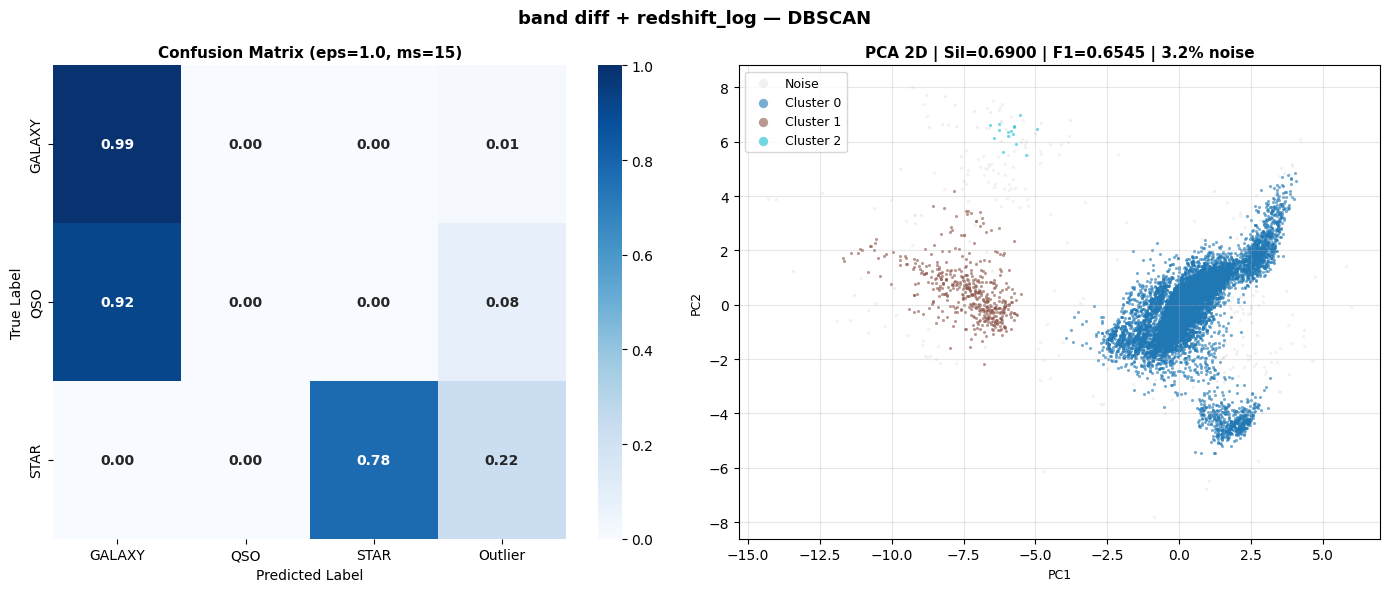

In [5]:
# ------ Run this optimal model------

# Prepare Dataset (band diff + redshift_log)
df1 = X.copy()
title = 'band diff + redshift_log'

# Encode classes
le = LabelEncoder()
y_true = le.fit_transform(y)
class_names = le.classes_
GAL_IDX  = list(class_names).index('GALAXY')
QSO_IDX  = list(class_names).index('QSO')
STAR_IDX = list(class_names).index('STAR')
n = len(y_true)

# Helper function for cluster -> class mapping (majority voting)
def map_clusters_to_labels(y_true, labels):
    mapped = np.full_like(labels, fill_value=-1)
    for cluster in set(labels):
        if cluster == -1:
            continue
        mask = labels == cluster
        majority_label = mode(y_true[mask], keepdims=True).mode[0]
        mapped[mask] = majority_label
    return mapped

# Load model and run on data
db = joblib.load('../models/dbscan_model.pkl')
labels = db.labels_
eps_best = db.eps
ms_best  = db.min_samples

y_pred = map_clusters_to_labels(y_true, labels)
mask = labels != -1

# Metrics
sil      = silhouette_score(df1[mask], labels[mask]) if mask.sum() > 1 else float('nan')
f1       = f1_score(y_true[mask], y_pred[mask], average='macro')
ari      = adjusted_rand_score(y_true, labels)
nmi      = normalized_mutual_info_score(y_true, labels)
noise_pct = (labels == -1).mean() * 100
ch       = calinski_harabasz_score(df1[mask], labels[mask])
db_index = davies_bouldin_score(df1[mask], labels[mask])
dbcv = validity_index(df1[mask].values.astype(np.float64), labels[mask])

print(f"{title}: eps={eps_best}, min_samples={ms_best}")
print(f"\nSilhouette: {sil:.4f}")
print(f"F1 (macro): {f1:.4f}")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Calinski-Harabasz: {ch:.4f}")
print(f"Davies-Bouldin: {db_index:.4f}")
print(f"DBCV: {dbcv:.4f}")
print(f"Noise %: {noise_pct:.1f}%")

unique, counts = np.unique(labels, return_counts=True)
print(f"\n{title} — Cluster Composition")
print("─" * 50)
for lbl, cnt in zip(unique, counts):
    name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {name:>10}: {cnt:>5} points ({cnt/len(labels)*100:.1f}%)")

# Plot diagrams
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'{title} — DBSCAN', fontsize=13, fontweight='bold')

# Heatmap
confusion_full = np.zeros((3, 4), dtype=int)
col_map = {GAL_IDX: 0, QSO_IDX: 1, STAR_IDX: 2, -1: 3}
for i in range(n):
    confusion_full[y_true[i], col_map[y_pred[i]]] += 1

cm_norm = confusion_full / confusion_full.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=list(class_names) + ['Outlier'],
            yticklabels=class_names,
            ax=axes[0], annot_kws={'fontweight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_title(f'Confusion Matrix (eps={eps_best}, ms={ms_best})', fontsize=11, fontweight='bold')

# Visualisation (PCA 2D)
X2d = PCA(n_components=2, random_state=42).fit_transform(df1)

unique_labels = sorted(set(labels))
cmap = plt.get_cmap('tab10', 3)

for k in unique_labels:
    mask_k = labels == k
    color = 'lightgrey' if k == -1 else cmap(k)
    lbl = 'Noise' if k == -1 else f'Cluster {k}'
    axes[1].scatter(
        X2d[mask_k, 0], X2d[mask_k, 1],
        c=[color], s=5,
        alpha=0.3 if k == -1 else 0.6,
        label=lbl, linewidths=0
    )

axes[1].set_title(
    f'PCA 2D | Sil={sil:.4f} | F1={f1:.4f} | {noise_pct:.1f}% noise',
    fontsize=11, fontweight='bold'
)
axes[1].set_xlabel('PC1', fontsize=9)
axes[1].set_ylabel('PC2', fontsize=9)
axes[1].legend(fontsize=9, markerscale=3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 DBSCAN Evaluation

DBSCAN results with hyperparameters *(eps = 1.0, min_samples = 15)* :

Cluster Composition  
The model identifies two dominant clusters and a minor fragment:  
- Cluster 0: 8,932 points (91.8%)  
- Cluster 1: 470 points (4.8%)  
- Cluster 2: 15 points (0.2%)  
- Noise: 316 points (3.2%)

The PCA projection shows that **Cluster 0 dominates**, while Cluster 2 is poorly separated, likely outliers rather than being a meaningful class.

Simple Evaluation Metrics  
- **ARI: 0.5845 | NMI: 0.5301**  
  Moderate agreement with ground truth; STAR vs GALAXY separation is captured, but QSO is not  

Key Limitations  
- **Hyperparameter Sensitivity**  
  Cluster results can differ greatly based on hyperparameters chosen  
- **Varying Densities**  
  2 of the clusters' regions most likely overlap in density, causing them to merge into a dominant cluster  

Conclusion:

DBSCAN is not well-suited for this dataset, effectively collapsing a three-class problem into two clusters and failing to isolate QSOs (in hindsight). A more flexible approach such as **HDBSCAN** (for varying densities based on what we see from the PCA plot)

## 4. HDBSCAN

### 4.1 HDBSCAN Overview

As mentioned, this algorithm is well-suited for datasets with varying densities and cluster sizes. HDBSCAN extends DBSCAN by incorporating a hierarchical clustering framework and extracting flat clusters based on cluster stability. Unlike DBSCAN, which relies on a single global density threshold, HDBSCAN constructs a hierarchy of clusters using a minimum spanning tree representation of the data. This hierarchical approach allows HDBSCAN to adapt to local density variations, enabling the detection of clusters that differ in density and structure. As a result, it is more robust in complex datasets where traditional density-based methods, such as DBSCAN, struggle to separate overlapping or unevenly distributed regions (Amalina & Fauzan, 2024).

The grid search ranges for `min_cluster_size` in this study were inspired by Logan & Fotopoulou (2020), who demonstrated that carefully exploring these hyperparameters helps HDBSCAN identify meaningful structures in astronomical datasets while balancing the trade-off between cluster granularity and noise.

In [6]:
# ------ Grid Search for best model (NO NEED TO RUN), optimal model loaded in next code block ------

# Encode classes 
le = LabelEncoder()
y_true = le.fit_transform(y)
class_names = le.classes_
GAL_IDX  = list(class_names).index('GALAXY')
QSO_IDX  = list(class_names).index('QSO')
STAR_IDX = list(class_names).index('STAR')

n = len(y_true)

# Grid search parameters 
mcs_values = (
    list(range(2,   70,   1))  +
    list(range(70,  100,  2))  +
    list(range(100, 120,  5))  +
    list(range(120, 200, 20))  
)

best = {'silhouette': -1, 'mcs': None, 'labels': None, 'ch': None, 'db': None, 'model': None}

# HDBSCAN Grid Search 
for mcs in mcs_values:
    clf = hdbscan.HDBSCAN(min_cluster_size=mcs, metric='euclidean').fit(X)
    hard_labels = clf.labels_

    n_clusters = len(set(hard_labels[hard_labels != -1]))
    if n_clusters < 2:
        continue

    valid_mask = hard_labels != -1
    silhouette = silhouette_score(X.values[valid_mask], hard_labels[valid_mask])

    if silhouette > best['silhouette']:
        best['silhouette'] = silhouette
        best['mcs'] = mcs
        best['model'] = clf

        cluster_to_class = {}
        for lbl in [l for l in sorted(set(hard_labels)) if l != -1]:
            mask = hard_labels == lbl
            majority = mode(y_true[mask], keepdims=True).mode[0]
            cluster_to_class[lbl] = majority

        final_labels = np.full(n, -1)
        for i in range(n):
            lbl = hard_labels[i]
            if lbl != -1:
                final_labels[i] = cluster_to_class[lbl]
        best['labels'] = final_labels.copy()

        best['ch'] = calinski_harabasz_score(X.values[valid_mask], hard_labels[valid_mask])
        best['db'] = davies_bouldin_score(X.values[valid_mask], hard_labels[valid_mask])

# Save the best model only
os.makedirs('../models', exist_ok=True)
joblib.dump(best['model'], '../models/hdbscan_model_1.pkl')
print("HDBSCAN model saved to ../models/hdbscan_model_1.pkl")

HDBSCAN model saved to ../models/hdbscan_model_1.pkl



── Overall Metrics ─────────────────────────────────────
  Outliers: 863 (8.9%)
  ARI:      0.7752
  NMI:      0.6396

Calinski-Harabasz: 5970.0091  Davies-Bouldin: 0.4276  Silhouette: 0.6040  DBCV: 0.4132

── Cluster sizes ────
  Noise: 863 points (8.9%)
  Cluster 0: 406 points (4.2%)
  Cluster 1: 397 points (4.1%)
  Cluster 2: 8,067 points (82.9%)

── Per-class F1 (incl. outliers as misclassified) ──────
  GALAXY: F1=0.9714
     QSO: F1=0.7338
    STAR: F1=0.7856


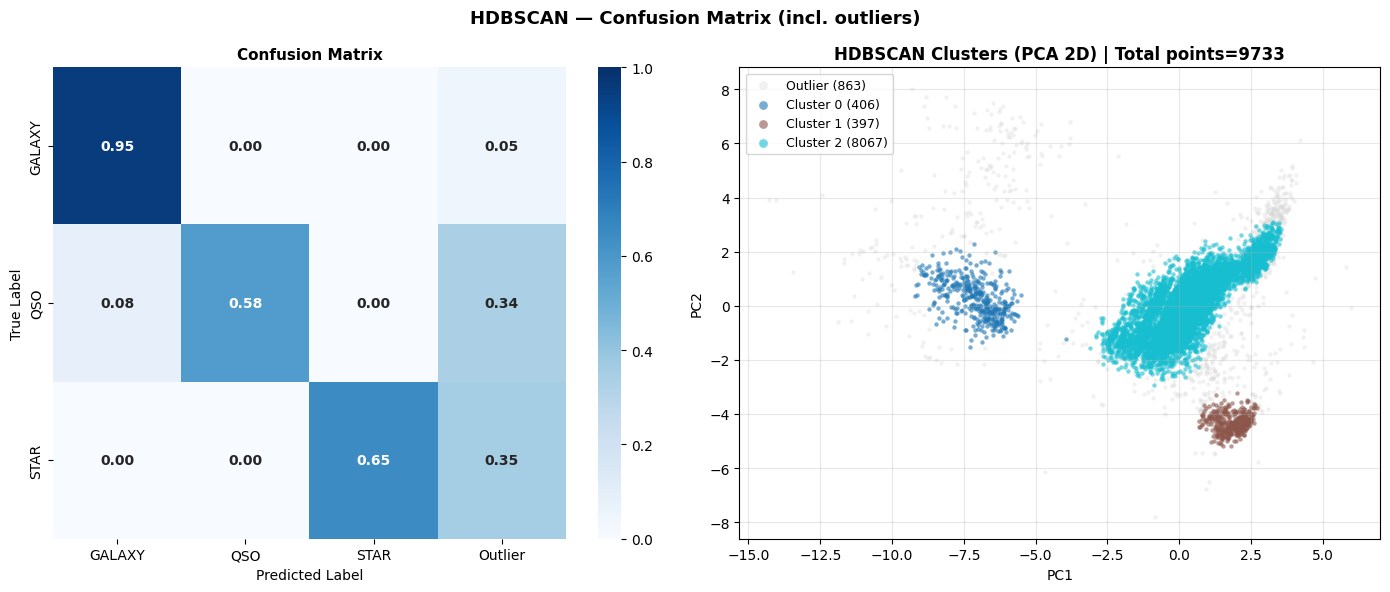

In [7]:
# ------ Run this optimal model------

# Encode classes
le = LabelEncoder()
y_true = le.fit_transform(y)
class_names = le.classes_
GAL_IDX  = list(class_names).index('GALAXY')
QSO_IDX  = list(class_names).index('QSO')
STAR_IDX = list(class_names).index('STAR')

n = len(y_true)

# Load model and run on data
clf = joblib.load('../models/hdbscan_model_1.pkl')
hard_labels = clf.labels_

# Map clusters -> class (majority vote)
cluster_to_class = {}
for lbl in [l for l in sorted(set(hard_labels)) if l != -1]:
    mask = hard_labels == lbl
    majority = mode(y_true[mask], keepdims=True).mode[0]
    cluster_to_class[lbl] = majority

# Assign cluster points to class
final_labels = np.full(n, -1)
for i in range(n):
    lbl = hard_labels[i]
    if lbl != -1:
        final_labels[i] = cluster_to_class[lbl]

valid_mask = hard_labels != -1

# Overall metrics
noise_pct = (final_labels == -1).mean() * 100
ari = adjusted_rand_score(y_true, final_labels)
nmi = normalized_mutual_info_score(y_true, final_labels)
ch  = calinski_harabasz_score(X.values[valid_mask], hard_labels[valid_mask])
db  = davies_bouldin_score(X.values[valid_mask], hard_labels[valid_mask])
sil = silhouette_score(X.values[valid_mask], hard_labels[valid_mask])
dbcv = validity_index(X.values[valid_mask].astype(np.float64), hard_labels[valid_mask])

print("\n── Overall Metrics ─────────────────────────────────────")
print(f"  Outliers: {(final_labels==-1).sum()} ({noise_pct:.1f}%)")
print(f"  ARI:      {ari:.4f}")
print(f"  NMI:      {nmi:.4f}")

print(f"\nCalinski-Harabasz: {ch:.4f}  Davies-Bouldin: {db:.4f}  Silhouette: {sil:.4f}  DBCV: {dbcv:.4f}")

# Cluster sizes including outliers
unique, counts = np.unique(hard_labels, return_counts=True)
print("\n── Cluster sizes ────")
for lbl, cnt in zip(unique, counts):
    name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {name}: {cnt:,} points ({cnt/len(hard_labels)*100:.1f}%)")

# Per-class F1
print("\n── Per-class F1 (incl. outliers as misclassified) ──────")
for cls_name, cls_idx in [('GALAXY', GAL_IDX), ('QSO', QSO_IDX), ('STAR', STAR_IDX)]:
    y_bin_true = (y_true == cls_idx).astype(int)
    y_bin_pred = (final_labels == cls_idx).astype(int)
    f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)
    print(f"  {cls_name:>6}: F1={f1:.4f}")

# Plot diagrams
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('HDBSCAN — Confusion Matrix (incl. outliers)',
             fontsize=13, fontweight='bold')

# Heatmap
confusion_full = np.zeros((3, 4), dtype=int)
col_map = {GAL_IDX: 0, QSO_IDX: 1, STAR_IDX: 2, -1: 3}
for i in range(n):
    confusion_full[y_true[i], col_map[final_labels[i]]] += 1

cm_norm = confusion_full / confusion_full.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=list(class_names) + ['Outlier'],
            yticklabels=class_names,
            ax=axes[0], annot_kws={'fontweight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_title('Confusion Matrix', fontsize=11, fontweight='bold')

# PCA Visualisation
X2d = PCA(n_components=2, random_state=42).fit_transform(X)
unique_labels = sorted(set(final_labels))
cmap = plt.get_cmap('tab10', len(class_names))

for lbl in unique_labels:
    mask = hard_labels == lbl
    if lbl == -1:
        color = 'lightgrey'
        label_name = 'Outlier'
        alpha = 0.3
    else:
        color = cmap(lbl)
        label_name = f'Cluster {lbl}'
        alpha = 0.6
    axes[1].scatter(X2d[mask, 0], X2d[mask, 1],
                    c=[color], s=10, alpha=alpha,
                    label=f"{label_name} ({mask.sum()})", linewidths=0)

axes[1].set_title(f'HDBSCAN Clusters (PCA 2D) | Total points={n}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1', fontsize=10)
axes[1].set_ylabel('PC2', fontsize=10)
axes[1].legend(fontsize=9, markerscale=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 HDBSCAN Initial Results

Applying HDBSCAN with a minimum cluster size (mcs) of 160 significantly improved the separation of clusters compared to DBSCAN. The model now identifies 3 distinct clusters corresponding to the astronomical classes (GALAXY, QSO, and STAR). This demonstrates that the hierarchical approach and the minimum cluster size parameter help HDBSCAN adapt to varying densities and avoid merging smaller clusters into a dominant mega-cluster, which was a limitation of DBSCAN.

However, the model also identifies a relatively large number of outliers (863 points, 8.9%). This is a consequence of the large min_cluster_size, which prevents smaller dense pockets from forming separate clusters. While this reduces false merging of clusters, it also increases the number of points labeled as noise.

Overall, HDBSCAN effectively captures the underlying three-class structure with improved cluster separation, while the choice of min_cluster_size balances cluster robustness against the number of outliers.

Simple Evaluation Metrics
- **ARI: 0.7752 | NMI: 0.6396**  
  Mid to strong agreement with ground truth; effective separation of all classes with reduced outliers compared to DBSCAN.

### 4.3 HDBSCAN with min_samples Adjustment

In [8]:
# ------ Grid Search for best model (NO NEED TO RUN), optimal model loaded in next code block ------

# Encode classes 
le = LabelEncoder()
y_true = le.fit_transform(y)
class_names = le.classes_
GAL_IDX  = list(class_names).index('GALAXY')
QSO_IDX  = list(class_names).index('QSO')
STAR_IDX = list(class_names).index('STAR')

n = len(y_true)

# HDBSCAN model
mcs = 160

best = {'silhouette': -1, 'min_samples': None, 'labels': None, 'ch': None, 'db': None, 'model': None}

for min_samples in range(5, 31, 5):

    clf = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=min_samples,
        metric='euclidean'
    ).fit(X)

    hard_labels = clf.labels_

    n_clusters = len(set(hard_labels[hard_labels != -1]))
    if n_clusters < 2:
        continue

    valid_mask = hard_labels != -1
    if valid_mask.sum() < 2:
        continue

    silhouette = silhouette_score(X.values[valid_mask], hard_labels[valid_mask])

    if silhouette > best['silhouette']:
        best['silhouette'] = silhouette
        best['min_samples'] = min_samples
        best['model'] = clf

        cluster_to_class = {}
        for lbl in [l for l in sorted(set(hard_labels)) if l != -1]:
            mask = hard_labels == lbl
            majority = mode(y_true[mask], keepdims=True).mode[0]
            cluster_to_class[lbl] = majority

        final_labels = np.full(n, -1)
        for i in range(n):
            lbl = hard_labels[i]
            if lbl != -1:
                final_labels[i] = cluster_to_class[lbl]
        best['labels'] = final_labels.copy()

        best['ch'] = calinski_harabasz_score(X.values[valid_mask], hard_labels[valid_mask])
        best['db'] = davies_bouldin_score(X.values[valid_mask], hard_labels[valid_mask])

# Save the best model only
os.makedirs('../models', exist_ok=True)
joblib.dump(best['model'], '../models/hdbscan_model_2.pkl')
print("HDBSCAN model saved to '../models/hdbscan_model_2.pkl'")

HDBSCAN model saved to '../models/hdbscan_model_2.pkl'



Best min_cluster_size: mcs=160, min_samples=25, Silhouette=0.5804

── Overall Metrics ─────────────────────────────────────
  Outliers: 523 (5.4%)
  ARI:      0.8528
  NMI:      0.7210

Calinski-Harabasz: 6209.6580  Davies-Bouldin: 0.4699  Silhouette: 0.5804  DBCV: 0.1064

── Cluster sizes ────
  Noise: 523 points (5.4%)
  Cluster 0: 478 points (4.9%)
  Cluster 1: 8,268 points (84.9%)
  Cluster 2: 464 points (4.8%)

── Per-class F1 (incl. outliers as misclassified) ──────
  GALAXY: F1=0.9826
     QSO: F1=0.8042
    STAR: F1=0.8667


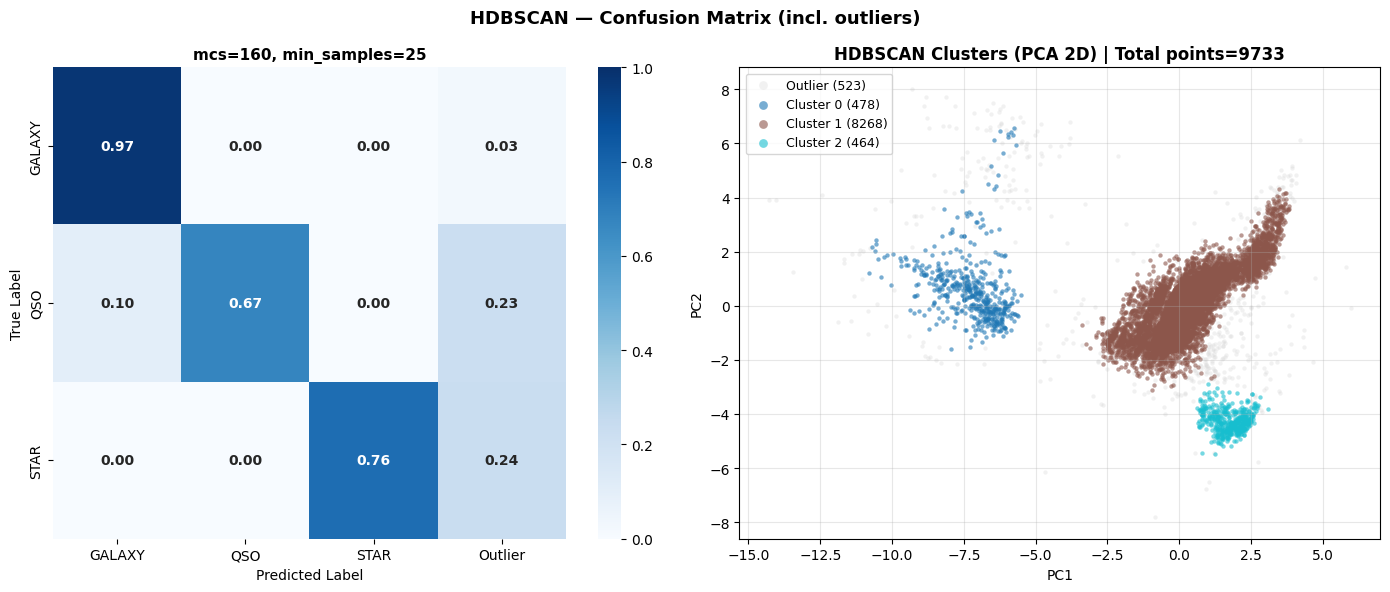

In [9]:
# ------ Run this optimal model------

# Encode classes
le = LabelEncoder()
y_true = le.fit_transform(y)
class_names = le.classes_
GAL_IDX  = list(class_names).index('GALAXY')
QSO_IDX  = list(class_names).index('QSO')
STAR_IDX = list(class_names).index('STAR')

n = len(y_true)

# Load model and run on data
clf = joblib.load('../models/hdbscan_model_2.pkl')
hard_labels = clf.labels_

# Map clusters -> class (majority vote)
cluster_to_class = {}
for lbl in [l for l in sorted(set(hard_labels)) if l != -1]:
    mask = hard_labels == lbl
    majority = mode(y_true[mask], keepdims=True).mode[0]
    cluster_to_class[lbl] = majority

# Assign cluster points to class
final_labels = np.full(n, -1)
for i in range(n):
    lbl = hard_labels[i]
    if lbl != -1:
        final_labels[i] = cluster_to_class[lbl]

valid_mask = hard_labels != -1
mcs = clf.min_cluster_size
min_samples = clf.min_samples

print(f"\nBest min_cluster_size: mcs={mcs}, min_samples={min_samples}, Silhouette={silhouette_score(X.values[valid_mask], hard_labels[valid_mask]):.4f}")

# Overall metrics
noise_pct = (final_labels == -1).mean() * 100
ari = adjusted_rand_score(y_true, final_labels)
nmi = normalized_mutual_info_score(y_true, final_labels)
ch  = calinski_harabasz_score(X.values[valid_mask], hard_labels[valid_mask])
db  = davies_bouldin_score(X.values[valid_mask], hard_labels[valid_mask])
sil = silhouette_score(X.values[valid_mask], hard_labels[valid_mask])
dbcv = validity_index(X.values[valid_mask].astype(np.float64), hard_labels[valid_mask])

print("\n── Overall Metrics ─────────────────────────────────────")
print(f"  Outliers: {(final_labels==-1).sum()} ({noise_pct:.1f}%)")
print(f"  ARI:      {ari:.4f}")
print(f"  NMI:      {nmi:.4f}")

print(f"\nCalinski-Harabasz: {ch:.4f}  Davies-Bouldin: {db:.4f}  Silhouette: {sil:.4f}  DBCV: {dbcv:.4f}")

# Cluster sizes including outliers
unique, counts = np.unique(hard_labels, return_counts=True)
print("\n── Cluster sizes ────")
for lbl, cnt in zip(unique, counts):
    name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {name}: {cnt:,} points ({cnt/len(hard_labels)*100:.1f}%)")

# Per-class F1
print("\n── Per-class F1 (incl. outliers as misclassified) ──────")
for cls_name, cls_idx in [('GALAXY', GAL_IDX), ('QSO', QSO_IDX), ('STAR', STAR_IDX)]:
    y_bin_true = (y_true == cls_idx).astype(int)
    y_bin_pred = (final_labels == cls_idx).astype(int)
    f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)
    print(f"  {cls_name:>6}: F1={f1:.4f}")

# Plot diagrams
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('HDBSCAN — Confusion Matrix (incl. outliers)',
             fontsize=13, fontweight='bold')

# Heatmap
confusion_full = np.zeros((3, 4), dtype=int)
col_map = {GAL_IDX: 0, QSO_IDX: 1, STAR_IDX: 2, -1: 3}
for i in range(n):
    confusion_full[y_true[i], col_map[final_labels[i]]] += 1

cm_norm = confusion_full / confusion_full.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=list(class_names) + ['Outlier'],
            yticklabels=class_names,
            ax=axes[0], annot_kws={'fontweight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)
axes[0].set_title(f'mcs={mcs}, min_samples={min_samples}', fontsize=11, fontweight='bold')

# PCA Visualisation
X2d = PCA(n_components=2, random_state=42).fit_transform(X)
unique_labels = sorted(set(final_labels))
cmap = plt.get_cmap('tab10', len(class_names))

for lbl in unique_labels:
    mask = hard_labels == lbl
    if lbl == -1:
        color = 'lightgrey'
        label_name = 'Outlier'
        alpha = 0.3
    else:
        color = cmap(lbl)
        label_name = f'Cluster {lbl}'
        alpha = 0.6
    axes[1].scatter(X2d[mask, 0], X2d[mask, 1],
                    c=[color], s=10, alpha=alpha,
                    label=f"{label_name} ({mask.sum()})", linewidths=0)

axes[1].set_title(f'HDBSCAN Clusters (PCA 2D) | Total points={n}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1', fontsize=10)
axes[1].set_ylabel('PC2', fontsize=10)
axes[1].legend(fontsize=9, markerscale=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 Final HDBSCAN Evaluation

For the final HDBSCAN model, with `min_cluster_size` = 160 and `min_samples` = 25, the results show improved cluster assignment and fewer outliers. The overall metrics indicate strong performance:

- Outliers: 523 points (5.4%)  
- **ARI: 0.8528 | NMI: 0.7210**  
  Excellent agreement with ground truth; robust separation of astronomical classes with much lower noise.  

As seen from the PCA visualization and cluster sizes, many points previously labeled as outliers now merge into the main clusters, reflecting better cluster cohesion. Although the silhouette score decreased slightly to 0.5804, this may not fully reflect the quality of the clustering and may underestimate performance in density-based methods that handle arbitrary shapes and varying densities. Hence, looking at the PCA plot to assess the performance qualitatively is also important.

## 5. Limitations

While density-based clustering methods like DBSCAN and HDBSCAN offer advantages in handling arbitrary cluster shapes and noise, they come with several limitations in the context of this astronomical dataset:

- **Hyperparameter Sensitivity**: Both DBSCAN and HDBSCAN require careful tuning of parameters (e.g., eps, min_samples, min_cluster_size). Suboptimal choices can lead to poor cluster separation or excessive noise labeling, as seen in DBSCAN's failure to isolate QSOs effectively.
  
- **Difficulty with Overlapping Densities**: Although HDBSCAN improves upon DBSCAN by adapting to varying densities, regions with highly overlapping clusters (e.g., GALAXY and QSO in certain feature spaces) may still result in merged clusters or misclassifications.

- **Outlier Handling**: While noise detection is a strength, the proportion of outliers (e.g., 5.4% in the final HDBSCAN model) may include valid data points that do not fit the density criteria, potentially leading to information loss.

- **Scalability and Interpretability**: For larger datasets, computational costs can increase, and the lack of probabilistic outputs (unlike GMM) makes it harder to quantify uncertainty in cluster assignments.

These limitations highlight the need for complementary approaches in complex, multi-class scenarios.

## 6. Conclusion

In this notebook, we explored density-based clustering methods for classifying astronomical objects (GALAXY, QSO, STAR) using photometric features. DBSCAN served as a baseline but struggled with hyperparameter sensitivity and varying densities, resulting in poor separation of QSOs and a dominant cluster.

HDBSCAN, with its hierarchical approach, provided significant improvements by adapting to local density variations, achieving better cluster separation with an ARI of 0.8528 and NMI of 0.7210 in the final model. The reduction in outliers from 8.9% to 5.4% further demonstrated its robustness.

Overall, HDBSCAN outperformed DBSCAN, effectively capturing the three-class structure while maintaining unsupervised model selection based on silhouette scores and internal metrics. However, challenges with overlapping densities and hyperparameter tuning underscore the need for further exploration.

## 7. Transition to Other Models

While density-based methods excel at detecting clusters of arbitrary shapes and handling noise, they may not fully address scenarios with highly overlapping or blurred class boundaries, as observed in the astronomical data where GALAXY, QSO, and STAR classes can intermix in feature space.

The next notebook explores Gaussian Mixture Models (GMM), a probabilistic approach that models data as a mixture of Gaussian distributions. GMM can provide soft cluster assignments, quantify uncertainty, and potentially better handle overlapping clusters by allowing elliptical shapes and probabilistic memberships. This complements the hard assignments of DBSCAN and HDBSCAN, offering insights into class probabilities and potentially improving classification in complex datasets.